# White-box Attack on CIFAR10

In [1]:
# Always start at base directory for imports
%cd
%cd dev2/scaling-laws-ecnn/
%load_ext autoreload
%autoreload 2
import pandas as pd
pd.set_option('display.max_columns', None)
import torch
from typing import List

import torch
import torch.nn as nn
import foolbox as fb
from torchattacks import PGD
from autoattack import AutoAttack
#from robustbench.utils import clean_accuracy


import sys
import os
sys.path.append(f"{os.getcwd()}")
from training import utils
from training.model_instantiate import hydra_compose 
from experiments.d_application.adversarial_attack.state import EvaluationState

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

/home/frischs
/home/frischs/dev2/scaling-laws-ecnn


In [2]:
model, dataloaders = hydra_compose(overrides=["training=isic2019-training", "model=efficientnet"])

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
Using cache found in /home/frischs/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/home/frischs/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/frischs/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(


{'model_building_time': 0.8145664636977017, 'param_count': 4.017796, 'GFLOPs': 4.950417408}


In [3]:
mean= [0.38250651955604553, 0.23592887818813324, 0.14257268607616425]
std= [0.324453204870224, 0.21356910467147827, 0.15683040022850037]

mean = torch.tensor(mean).to(device)
std = torch.tensor(std).to(device)

train_dataloader = dataloaders["train"]
for i, out_dataloader in enumerate(train_dataloader):
    images, labels, meta_data = utils.get_out_dataloader(out_dataloader)
    print(images.shape)
    print(labels.shape)
    break

images = images.to(device)
labels = labels.to(device)

images = images * std[:, None, None] + mean[:, None, None]

torch.Size([64, 3, 96, 96])
torch.Size([64])


In [10]:

#EvaluationState.from_disk(aa_state_path)

SyntaxError: invalid syntax (933578692.py, line 1)

In [4]:
aa_state_path="~/logs/aa_state.txt"

adversary = AutoAttack(model, norm='Linf', eps=8/255)
adversary.apgd.n_restarts = 1
x_adv = adversary.run_standard_evaluation(images, labels)
to_print = adversary.clean_accuracy(x_adv, labels)

#aa_state = EvaluationState.from_disk(aa_state_path)
#assert aa_state.robust_flags is not None
#adv_accuracy = aa_state.robust_flags.mean().item()


#adv_accuracy = clean_accuracy(model, x_adv, labels)

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square
initial accuracy: 6.25%


In [12]:
x_adv

tensor([[[[-1.2062e+00, -1.2062e+00, -1.2062e+00,  ..., -1.2253e+00,
           -1.2253e+00, -1.2253e+00],
          [-1.2062e+00, -1.2062e+00, -1.2157e+00,  ..., -1.2253e+00,
           -1.2253e+00, -1.2253e+00],
          [-1.2062e+00, -1.2062e+00, -1.2157e+00,  ..., -1.2253e+00,
           -1.2253e+00, -1.2253e+00],
          ...,
          [-1.2348e+00, -1.2348e+00, -1.2348e+00,  ..., -1.2157e+00,
           -1.2157e+00, -1.2157e+00],
          [-1.2444e+00, -1.2348e+00, -1.2444e+00,  ..., -1.2157e+00,
           -1.2157e+00, -1.2157e+00],
          [-1.2348e+00, -1.2348e+00, -1.2348e+00,  ..., -1.2157e+00,
           -1.2157e+00, -1.2157e+00]],

         [[-4.9726e-01, -4.9726e-01, -4.9726e-01,  ..., -5.0861e-01,
           -5.0861e-01, -5.0861e-01],
          [-4.9726e-01, -4.9726e-01, -5.0294e-01,  ..., -5.0861e-01,
           -5.0861e-01, -5.0861e-01],
          [-4.9726e-01, -4.9726e-01, -5.0294e-01,  ..., -5.0861e-01,
           -5.0861e-01, -5.0861e-01],
          ...,
     

In [ ]:
adversary = AutoAttack(model, norm='Linf', eps=8/255)

In [6]:
#model = model.eval()

mean= [0.38250651955604553, 0.23592887818813324, 0.14257268607616425]
std= [0.324453204870224, 0.21356910467147827, 0.15683040022850037]

mean = torch.tensor(mean).to(device)
std = torch.tensor(std).to(device)

preprocessing = dict(mean=mean, std=std, axis=-3)
bounds = (0, 1)
fmodel = fb.PyTorchModel(model, bounds=bounds, preprocessing=preprocessing)

/home/frischs/anaconda3/envs/scaling-adversarial/lib/python3.11/site-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(


## Load model and data

In [25]:
images.min().item()

0.0

In [33]:
fb.utils.accuracy(fmodel, images, labels)

attack = fb.attacks.LinfPGD()
epsilons = [0.01] # [0.0, 0.001, 0.01, 0.03, 0.1, 0.3, 0.5, 1.0]
_, advs, success = attack(fmodel, images, labels, epsilons=epsilons)

In [35]:
success

tensor([[ True, False, False,  True,  True,  True, False,  True,  True,  True,
          True,  True,  True,  True,  True,  True, False,  True, False,  True,
          True,  True, False,  True, False, False, False,  True,  True,  True,
         False, False,  True,  True, False, False,  True, False,  True, False,
         False, False,  True, False, False,  True,  True,  True, False,  True,
          True,  True, False, False,  True, False, False, False, False, False,
         False, False,  True, False]], device='cuda:0')

In [ ]:
fmodel = PyTorchModel(model, bounds = (0, 1), preprocessing = dict(mean = mean, std = std)) 
epsilons = [0.01, 0.03, 0.1, 0.3, 0.5]
cnt, total = torch.zeros(len(epsilons)).to(device),\
                torch.zeros(len(epsilons)).to(device)



correct = torch.zeros(len(epsilons)).to(device)

for _, (images, labels) in enumerate(eval_loader):
    images = images.to(device)
    labels = labels.to(device)

    images = images * std[:, None, None] + mean[:, None, None]

    _, advs_list, success = attack(fmodel, images, labels, epsilons = epsilons)
    cnt += success.sum(axis = 1)
    total += images.shape[0]

    for i, advs in enumerate(advs_list):
        preds = model(advs).argmax(dim=1)
        correct[i] += (preds == labels).sum().item()  # Compute accuracy for each epsilon

print(f"Success rate vector: {cnt / total}")
print(f"Accuracy vector for each epsilon: {correct / total}")

In [9]:
#sys.path.insert(0, '..')
import robustbench
from robustbench.data import load_cifar10
from robustbench.utils import load_model, clean_accuracy

#images, labels = load_cifar10(n_examples=5)
print('[Data loaded]')

device = "cuda"
#model = load_model('Standard', norm='Linf').to(device)
acc = clean_accuracy(model, images.to(device), labels.to(device))
print('[Model loaded]')
print('Acc: %2.2f %%'%(acc*100))

100%|██████████| 170498071/170498071 [00:09<00:00, 18470305.83it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
[Data loaded]
[Model loaded]
Acc: 20.00 %


## Adversarial Attack

In [12]:
#from utils import imshow, get_pred
from autoattack import AutoAttack
adversary = AutoAttack(model, norm='Linf', eps=8/255, version='custom', attacks_to_run=['apgd-ce', 'apgd-dlr'])
adversary.apgd.n_restarts = 1
x_adv = adversary.run_standard_evaluation(x_test, y_test)

ImportError: cannot import name 'zero_gradients' from 'autoattack.other_utils' (/home/frischs/anaconda3/envs/scaling-adversarial/lib/python3.11/site-packages/autoattack/other_utils.py)

In [6]:
atk = PGD(model, eps=8/255, alpha=2/225, steps=10, random_start=True)
print(atk)

PGD(model_name=EquivariantNASNet, device=cuda:0, attack_mode=default, targeted=False, normalization_used=False, eps=0.03137254901960784, alpha=0.008888888888888889, steps=10, random_start=True)


In [13]:
import robustbench
from robustbench import benchmark

ModuleNotFoundError: No module named 'autoattack.state'

In [38]:
from robustbench import benchmark
clean_acc, robust_acc = benchmark(model,
                                  dataset='cifar10',
                                  threat_model='Linf')

ImportError: cannot import name 'benchmark' from 'robustbench' (/home/frischs/anaconda3/envs/scaling-adversarial/lib/python3.11/site-packages/robustbench/__init__.py)

In [8]:
# When normalization used:
atk.set_normalization_used(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [9]:
adv_images = atk(images, labels)

ValueError: Input must have a range [0, 1] (max: 1.636125922203064, min: 0.20145511627197266)

In [24]:
output = model(adv_images)
pred = output.argmax(dim=1, keepdim=True)
pred

tensor([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [7],
        [1],
        [7],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [7],
        [1],
        [1],
        [1]], device='cuda:0')

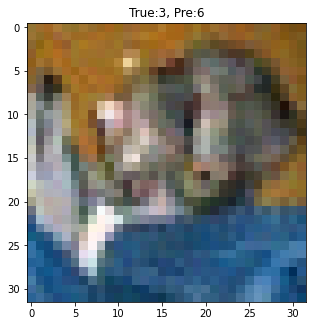

In [6]:
idx = 0
pre = get_pred(model, adv_images[idx:idx+1], device)
imshow(adv_images[idx:idx+1], title="True:%d, Pre:%d"%(labels[idx], pre))